In [195]:
from HGEMMD import HGEMMD
import os, re, itertools
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [196]:
data_dir = './data/data_MOGONET/BRCA'
data_list = []
data_raw_list = []
for i in range(1, 4): # num_view = 3
    data_train_raw = np.loadtxt(os.path.join(data_dir, str(i) + "_tr.csv"), delimiter=',')
    data_test_raw = np.loadtxt(os.path.join(data_dir, str(i) + "_te.csv"), delimiter=',')
    data_train_min = np.min(data_train_raw, axis=0, keepdims=True) # shape: (1, num_feature)
    data_train_max = np.max(data_train_raw, axis=0, keepdims=True) # shape: (1, num_feature)
    data_train = (data_train_raw - data_train_min)/(data_train_max - data_train_min + 1e-10) # make the data in [0, 1]
    data_test = (data_test_raw - data_train_min)/(data_train_max - data_train_min + 1e-10) # make the data in [0, 1]
    # data_train_list.append(data_train.astype(float))
    # data_test_list.append(data_test.astype(float))
    data_raw_list.append(np.concatenate([data_train_raw, data_test_raw], axis=0)) # shape: (num_train+num_test, num_feature)
    data_list.append(np.concatenate([data_train, data_test], axis=0)) # shape: (num_train+num_test, num_feature)
label_train = np.loadtxt(os.path.join(data_dir, "labels_tr.csv"), delimiter=',').astype(int)
label_test = np.loadtxt(os.path.join(data_dir, "labels_te.csv"), delimiter=',').astype(int)
label = np.concatenate([label_train, label_test], axis=0) # shape: (num_train+num_test, )
data_train_indices = np.arange(label_train.shape[0])
data_test_indices = np.arange(label_train.shape[0], label_train.shape[0] + label_test.shape[0])
# data_list: list of numpy arrays, each array is a matrix with shape (num_train+num_test, num_feature)
# label: numpy array with shape (num_train+num_test, )
# data_train_indices: numpy array with shape (num_train, )
# data_test_indices: numpy array with shape (num_test, )
print('data_list mRNA shape:', data_list[0].shape)
print('data_list meth shape:', data_list[1].shape)
print('data_list miRNA shape:', data_list[2].shape)
print('label shape:', label.shape)
print('data_train_indices shape:', data_train_indices.shape)
print('data_test_indices shape:', data_test_indices.shape)

data_list mRNA shape: (875, 1000)
data_list meth shape: (875, 1000)
data_list miRNA shape: (875, 503)
label shape: (875,)
data_train_indices shape: (612,)
data_test_indices shape: (263,)


label count: [115 131  46 436 147]


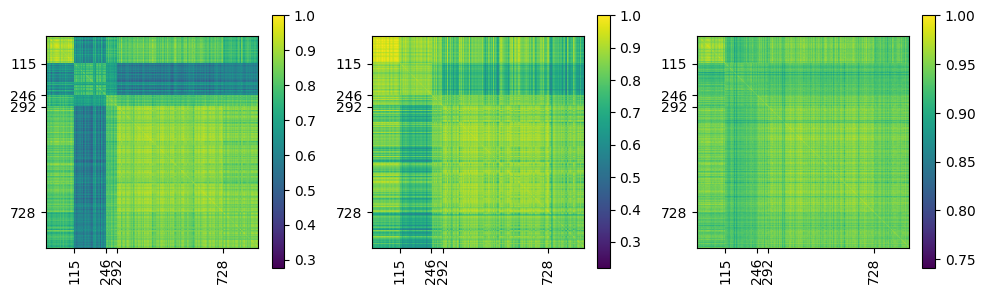

In [225]:
#### Distance Matrix using euclidean distance
data_modality_1_raw = data_raw_list[0]
data_modality_1 = data_list[0]
data_modality_1_pcc = np.corrcoef(data_modality_1_raw)
data_modality_2_raw = data_raw_list[1]
data_modality_2 = data_list[1]
data_modality_2_pcc = np.corrcoef(data_modality_2_raw)
data_modality_3_raw = data_raw_list[2]
data_modality_3 = data_list[2]
data_modality_3_pcc = np.corrcoef(data_modality_3_raw)

# plot the data_modality_similarity heatmap
_, label_count = np.unique(label, return_counts=True)
label_position = np.cumsum(label_count)
print('label count:', label_count)
data_modality_1_similarity = data_modality_1_pcc
data_modality_2_similarity = data_modality_2_pcc
data_modality_3_similarity = data_modality_3_pcc
fig, ax = plt.subplots(figsize=(10, 3), ncols=3)
data_modality_1_similarity = data_modality_1_similarity[np.argsort(label)]
data_modality_1_similarity = data_modality_1_similarity[:, np.argsort(label)]
ax[0].imshow(data_modality_1_similarity, cmap='viridis')
ax[0].set_xticks([i for i in label_position], labels=[i for i in label_position], rotation=90)
ax[0].set_yticks([i for i in label_position], labels=[i for i in label_position], rotation=0)
fig.colorbar(ax[0].imshow(data_modality_1_similarity, cmap='viridis'), ax=ax[0])
data_modality_2_similarity = data_modality_2_similarity[np.argsort(label)]
data_modality_2_similarity = data_modality_2_similarity[:, np.argsort(label)]
ax[1].imshow(data_modality_2_similarity, cmap='viridis')
ax[1].set_xticks([i for i in label_position], labels=[i for i in label_position], rotation=90)
ax[1].set_yticks([i for i in label_position], labels=[i for i in label_position], rotation=0)
fig.colorbar(ax[1].imshow(data_modality_2_similarity, cmap='viridis'), ax=ax[1])
data_modality_3_similarity = data_modality_3_similarity[np.argsort(label)]
data_modality_3_similarity = data_modality_3_similarity[:, np.argsort(label)]
ax[2].imshow(data_modality_3_similarity, cmap='viridis')
ax[2].set_xticks([i for i in label_position], labels=[i for i in label_position], rotation=90)
ax[2].set_yticks([i for i in label_position], labels=[i for i in label_position], rotation=0)
fig.colorbar(ax[2].imshow(data_modality_3_similarity, cmap='viridis'), ax=ax[2])
plt.tight_layout()

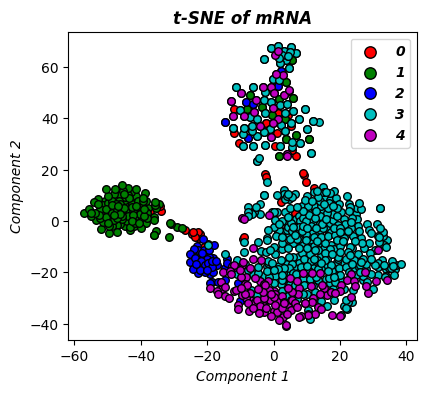

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# what is perplexity? perplexity is a parameter in t-SNE, it is the number of nearest neighbors that each point is assumed to have.
# Small perplexity means tsne pays more attention to the local structure of the data. So small cluster could be separated.
# Large perplexity means tsne pays more attention to the global structure of the data. So small cluster could be merged.
tsne_modality_1 = tsne.fit_transform(data_modality_1)

# plot the tsne_modality_1
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
plt.figure(figsize=(4.5, 4))
for i in range(len(np.unique(label))):
    plt.scatter(tsne_modality_1[label == i, 0], tsne_modality_1[label == i, 1], c=colors[i], label=i, edgecolor='k', s=30)
plt.legend(loc='upper right', fontsize=8, markerscale=1.5, prop={'size': 10, 'style': 'italic', 'weight': 'bold'})
plt.title('t-SNE of mRNA', fontsize=12, fontweight='bold', style='italic')
plt.xlabel('Component 1', fontsize=10, style='italic')
plt.ylabel('Component 2', fontsize=10, style='italic')
plt.show()

acc: 0.8593155893536122


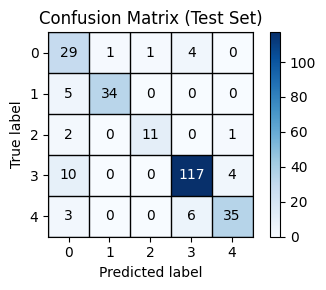

In [217]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=13)
knn_classifier.fit(data_modality_1_pcc[:len(label_train)], label_train)
test_pred_modality_1 = knn_classifier.predict(data_modality_1_pcc[len(label_train):])
acc = accuracy_score(label_test, test_pred_modality_1)
print('acc:', acc)
cm = confusion_matrix(label_test, test_pred_modality_1)

# # Plot the confusion matrix by seaborn
# plt.figure(figsize=(4, 3))
# ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linecolor='black', linewidths=1, square=True)
# ax.spines['top'].set_linewidth(2)
# ax.spines['bottom'].set_linewidth(2)
# ax.spines['left'].set_linewidth(2)
# ax.spines['right'].set_linewidth(2)
# ax.spines['top'].set_color('black')
# ax.spines['bottom'].set_color('black')
# ax.spines['left'].set_color('black')
# ax.spines['right'].set_color('black')
# ax.tick_params(axis='both', which='major', length=2, width=1, color='black')
# ax.tick_params(axis='both', which='minor', length=2, width=1, color='black')
# n_rows, n_cols = cm.shape
# ax.set_xlim(0-0.05, n_cols+0.05)
# ax.set_ylim(n_rows+0.05, 0-0.05)  # 注意：热图 y 轴是倒置的
# plt.tight_layout()
# plt.show()

# Plot the confusion matrix by matplotlib
plt.figure(figsize=(4, 3))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Test Set)')
plt.colorbar()
plt.xticks(np.arange(cm.shape[0]))
plt.yticks(np.arange(cm.shape[1]))
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="white" if cm[i, j] > (cm.max() / 2.) else "black")
for i in range(cm.shape[0]+1):
    plt.axhline(i-0.5, color='black', linewidth=1)
    plt.axvline(i-0.5, color='black', linewidth=1)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

acc: 0.714828897338403


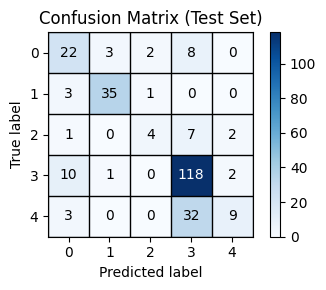

In [219]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=26)
knn_classifier.fit(data_modality_2_pcc[:len(label_train)], label_train)
test_pred_modality_2 = knn_classifier.predict(data_modality_2_pcc[len(label_train):])
acc = accuracy_score(label_test, test_pred_modality_2)
print('acc:', acc)
cm = confusion_matrix(label_test, test_pred_modality_2)
plt.figure(figsize=(4, 3))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Test Set)')
plt.colorbar()
plt.xticks(np.arange(cm.shape[0]))
plt.yticks(np.arange(cm.shape[1]))
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="white" if cm[i, j] > (cm.max() / 2.) else "black")
for i in range(cm.shape[0]+1):
    plt.axhline(i-0.5, color='black', linewidth=1)
    plt.axvline(i-0.5, color='black', linewidth=1)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

acc: 0.6121673003802282


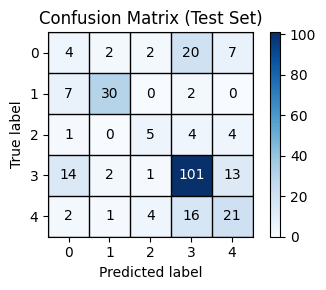

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=1)
knn_classifier.fit(data_modality_3_pcc[:len(label_train)], label_train)
test_pred_modality_3 = knn_classifier.predict(data_modality_3_pcc[len(label_train):])
acc = accuracy_score(label_test, test_pred_modality_3)
print('acc:', acc)
cm = confusion_matrix(label_test, test_pred_modality_3)
plt.figure(figsize=(4, 3))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Test Set)')
plt.colorbar()
plt.xticks(np.arange(cm.shape[0]))
plt.yticks(np.arange(cm.shape[1]))
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="white" if cm[i, j] > (cm.max() / 2.) else "black")
for i in range(cm.shape[0]+1):
    plt.axhline(i-0.5, color='black', linewidth=1)
    plt.axvline(i-0.5, color='black', linewidth=1)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

acc: 0.6996197718631179


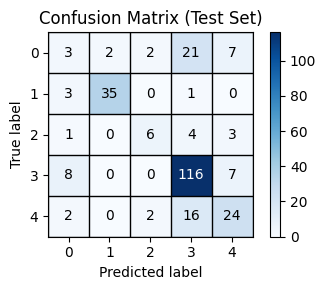

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def multimodal_knn_predict(X_train_list, X_test_list, y_train, k_list=[12, 150, 10], voting='soft', weights=None):
    """
    使用多个模态的 KNN 输出进行融合预测。
    参数：
    - X_train_list: list of np.ndarray, 每个模态的训练特征 (n_samples, n_features_i)
    - X_test_list:  list of np.ndarray, 每个模态的测试特征   (m_samples, n_features_i)
    - y_train: np.ndarray, 训练标签，长度为 n_samples
    - k: int, KNN 中的近邻数
    - voting: 'soft' 使用概率平均；'hard' 使用标签多数投票
    - weights: None 或 长度为模态数的列表，用于加权 soft voting
    返回：
    - final_pred: 融合后的预测标签 (np.ndarray, shape=[m_samples])
    """
    assert len(X_train_list) == len(X_test_list), "模态数不一致"
    num_modalities = len(X_train_list)
    proba_list = []
    label_list = []
    for i in range(num_modalities):
        clf = KNeighborsClassifier(n_neighbors=k_list[i])
        clf.fit(X_train_list[i], y_train)
        if voting == 'soft':
            proba = clf.predict_proba(X_test_list[i])
            proba_list.append(proba)
        elif voting == 'hard':
            pred = clf.predict(X_test_list[i])
            label_list.append(pred)
        else:
            raise ValueError("voting must be 'soft' or 'hard'")
    if voting == 'soft':
        proba_array = np.array(proba_list)  # shape: (num_modalities, m_samples, n_classes)
        if weights is not None:
            weights = np.array(weights).reshape(-1, 1, 1)  # shape: (num_modalities, 1, 1)
            avg_proba = np.sum(weights * proba_array, axis=0)
        else:
            avg_proba = np.mean(proba_array, axis=0)
        final_pred = np.argmax(avg_proba, axis=1)
    else:  # hard voting
        all_preds = np.stack(label_list, axis=0)  # shape: (num_modalities, m_samples)
        final_pred, _ = mode(all_preds, axis=0, keepdims=False)
    return final_pred

X_train_list = [data_modality_1_pcc[:len(label_train)], data_modality_2_pcc[:len(label_train)], data_modality_3_pcc[:len(label_train)]]
X_test_list = [data_modality_1_pcc[len(label_train):], data_modality_2_pcc[len(label_train):], data_modality_3_pcc[len(label_train):]]
y_train = label_train
y_test = label_test
final_pred = multimodal_knn_predict(X_train_list, X_test_list, y_train, k_list=[13, 26, 1], voting='soft', weights=[1, 1, 1])
acc = accuracy_score(y_test, final_pred)
print('acc:', acc)
cm = confusion_matrix(label_test, final_pred)
plt.figure(figsize=(4, 3))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Test Set)')
plt.colorbar()
plt.xticks(np.arange(cm.shape[0]))
plt.yticks(np.arange(cm.shape[1]))
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="white" if cm[i, j] > (cm.max() / 2.) else "black")
for i in range(cm.shape[0]+1):
    plt.axhline(i-0.5, color='black', linewidth=1)
    plt.axvline(i-0.5, color='black', linewidth=1)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()
